In [1]:
import os
import random
import copy

import numpy as np
import pandas as pd

from tqdm import tqdm

import wandb

import torch
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"egornovikov2005","key":"4009ea8efabcb47b4c1323756302ecd6"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:47<00:00, 22.8MB/s]



In [5]:
!mkdir -p /content/chest_xray_data
!unzip -q chest-xray-pneumonia.zip -d /content/chest_xray_data/

In [6]:
INPUT_DIR = '/content/chest_xray_data/chest_xray'

In [7]:
class CFG:
  api = "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"
  project = "gp5-project"
  entity = None
  num_epochs = 5
  train_batch_size = 32
  test_batch_size = 64
  num_workers = 2
  lr = 0.001
  seed = 42
  classes = ('NORMAL', 'PNEUMONIA')
  wandb = True

In [8]:
def class2dict(f):
  return dict((name, getattr(f, name)) for name in dir(f) if not name.startswith('__'))

In [9]:
def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [10]:
seed_everything(CFG.seed)

DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
DEVICE

device(type='cuda')

In [11]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
}

In [12]:
dataset = {ds: torchvision.datasets.ImageFolder(
    root=os.path.join(INPUT_DIR, ds),
    transform=data_transforms[ds]
) for ds in ['train', 'val', 'test']}

dataset_size = {ds: len(dataset[ds]) for ds in ['train', 'val', 'test']}
dataset_classes = dataset['train'].classes

print('classes:', dataset_classes, '\nsize:', dataset_size)

classes: ['NORMAL', 'PNEUMONIA'] 
size: {'train': 5216, 'val': 16, 'test': 624}


In [13]:
dataloader = {
    'train': torch.utils.data.DataLoader(dataset=dataset['train'], batch_size=CFG.train_batch_size, shuffle=True, num_workers=CFG.num_workers
    ),
    'val': torch.utils.data.DataLoader(dataset=dataset['val'], batch_size=CFG.test_batch_size, shuffle=False, num_workers=CFG.num_workers
    ),
    'test': torch.utils.data.DataLoader(dataset=dataset['test'], batch_size=CFG.test_batch_size, shuffle=False, num_workers=CFG.num_workers
    )
}

In [14]:
examples = enumerate(dataloader['train'])
batch_idx, (example_data, example_targets) = next(examples)

example_data.shape

torch.Size([32, 3, 224, 224])

# Простая модель CNN

In [15]:
class XRay_Net(torch.nn.Module):
    def __init__(self):
        super(XRay_Net, self).__init__()

        self.conv1 = torch.nn.Conv2d(3, 16, 3, padding=1)
        self.act1  = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(2, 2)

        self.conv2 = torch.nn.Conv2d(16, 32, 3, padding=1)
        self.act2  = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(2, 2)

        self.conv3 = torch.nn.Conv2d(32, 64, 3, padding=1)
        self.act3  = torch.nn.ReLU()
        self.pool3 = torch.nn.MaxPool2d(2, 2)

        self.fc1   = torch.nn.Linear(28 * 28 * 64, 256)
        self.act4  = torch.nn.ReLU()

        self.fc2   = torch.nn.Linear(256, 64)
        self.act5  = torch.nn.ReLU()

        self.fc3   = torch.nn.Linear(64, 2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.act1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.act2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.act3(x)
        x = self.pool3(x)

        x = x.view(x.size(0), x.size(1) * x.size(2) * x.size(3))

        x = self.fc1(x)
        x = self.act4(x)

        x = self.fc2(x)
        x = self.act5(x)

        x = self.fc3(x)

        return x

In [16]:
def train_model(
    model: torch.nn.Module,
    criterion: torch.nn.Module,
    optimizer: torch.nn.Module,
    sheduler: torch.nn.Module,
    epochs: int = 5,
    WANDB: bool = False
) -> tuple[torch.nn.Module, dict]:

    if WANDB:
        os.environ["WANDB_API_KEY"] = CFG.api
        wandb.init(project=CFG.project, entity=CFG.entity, reinit=True, config=class2dict(CFG))

    losses = {'train': [], 'val': []}
    accuracies = {'train': [], 'val': []}
    recalls = {'train': [], 'val': []}

    best_model_weights = copy.deepcopy(model.state_dict())
    best_accuracy = 0.

    model = model.to(DEVICE)

    if WANDB:
        wandb.watch(model, log='all')

    pneumonia_label = dataset_classes.index('PNEUMONIA')

    progress = tqdm(range(epochs), desc='Epoch:')

    for epoch in progress:
        for phase in ['train', 'val']:

            loss_accum = 0.
            corr_accum = 0

            true_pneumonia = 0
            correct_pneumonia = 0

            model.train(mode=(phase == 'train'))

            for inputs, labels in tqdm(dataloader[phase], desc=f'Phase {phase}:'):

                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                if phase == 'train':
                    optimizer.zero_grad()

                    outp = model(inputs)
                    loss = criterion(outp, labels)

                    loss.backward()
                    optimizer.step()

                else:
                    with torch.no_grad():
                        outp = model(inputs)
                        loss = criterion(outp, labels)

                preds = torch.argmax(outp, -1)

                loss_accum += loss.item() * inputs.size(0)
                corr_accum += torch.sum(preds == labels).item()

                true_pneumonia += torch.sum(labels == pneumonia_label).item()
                correct_pneumonia += torch.sum((preds == pneumonia_label) & (labels == pneumonia_label)).item()

            if phase == 'train':
                sheduler.step()

            epoch_loss = loss_accum / dataset_size[phase]
            epoch_accuracy = corr_accum / dataset_size[phase]

            if true_pneumonia != 0:
                epoch_recall = correct_pneumonia / true_pneumonia
            else:
                epoch_recall = 0

            losses[phase].append(epoch_loss)
            accuracies[phase].append(epoch_accuracy)
            recalls[phase].append(epoch_recall)

            progress.set_description(
                'loss: {:.4f}, acc: {:.4f}, recall: {:.4f}'.format(
                    epoch_loss,
                    epoch_accuracy,
                    epoch_recall
                )
            )

            if phase == 'val' and epoch_accuracy > best_accuracy:
                best_accuracy = epoch_accuracy
                best_model_weights = copy.deepcopy(model.state_dict())

                if WANDB:
                    wandb.log({
                        'best_val_accuracy': best_accuracy,
                        'best_val_recall': epoch_recall
                    })

            if WANDB:
                wandb.log({
                    'epoch': epoch + 1,
                    phase + '_loss': epoch_loss,
                    phase + '_accuracy': epoch_accuracy,
                    phase + '_recall': epoch_recall
                })

    model.load_state_dict(best_model_weights)

    return model, losses, accuracies, recalls

In [17]:
model_1 = XRay_Net()
model_1.to(DEVICE)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(), lr=CFG.lr)

sheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

In [18]:
model_1, losses_1, accuracies_1, recalls_1 = train_model(model_1,criterion,optimizer,sheduler,epochs=CFG.num_epochs,WANDB=CFG.wandb)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: snigirev576 (snigirev576-hse) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


loss: 0.2391, acc: 0.8750, recall: 1.0000: 100%|██████████| 5/5 [06:35<00:00, 79.07s/it]


In [27]:
torch.save(model_1.state_dict(), 'simple_cnn_model.pth')

if CFG.wandb:
    artifact = wandb.Artifact(
        name='simple_cnn_model',
        type='model'
    )

    artifact.add_file('simple_cnn_model.pth')
    wandb.log_artifact(artifact)

In [28]:
def show_metrics(metrics):
    plt.figure(figsize=(12, 8))
    plt.plot(metrics['train'], label='train')
    plt.plot(metrics['val'], label='val')
    plt.grid()
    plt.legend()
    plt.show()

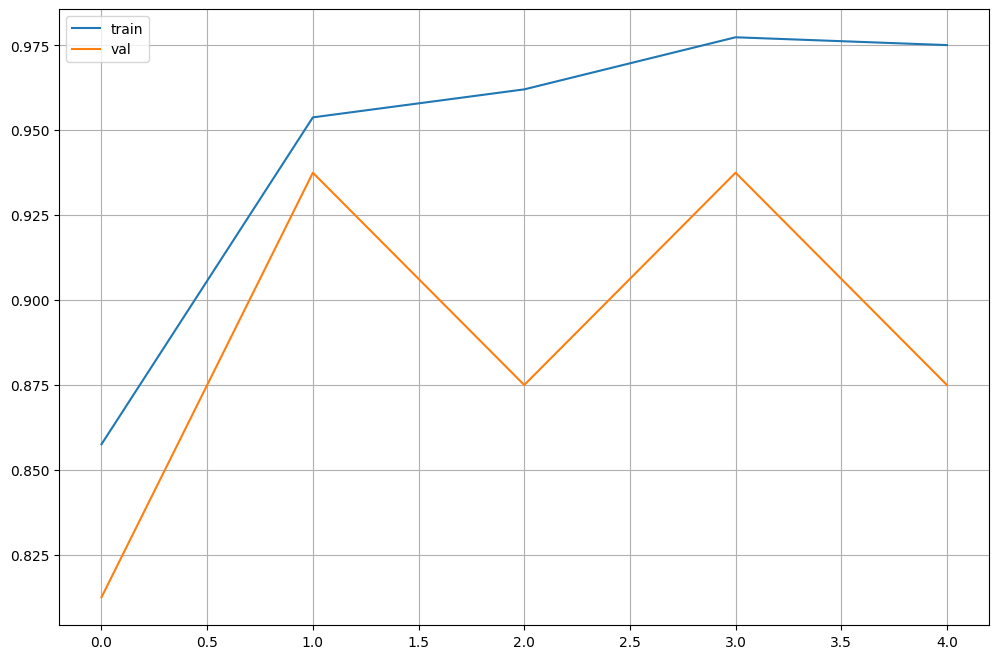

In [29]:
show_metrics(accuracies_1)

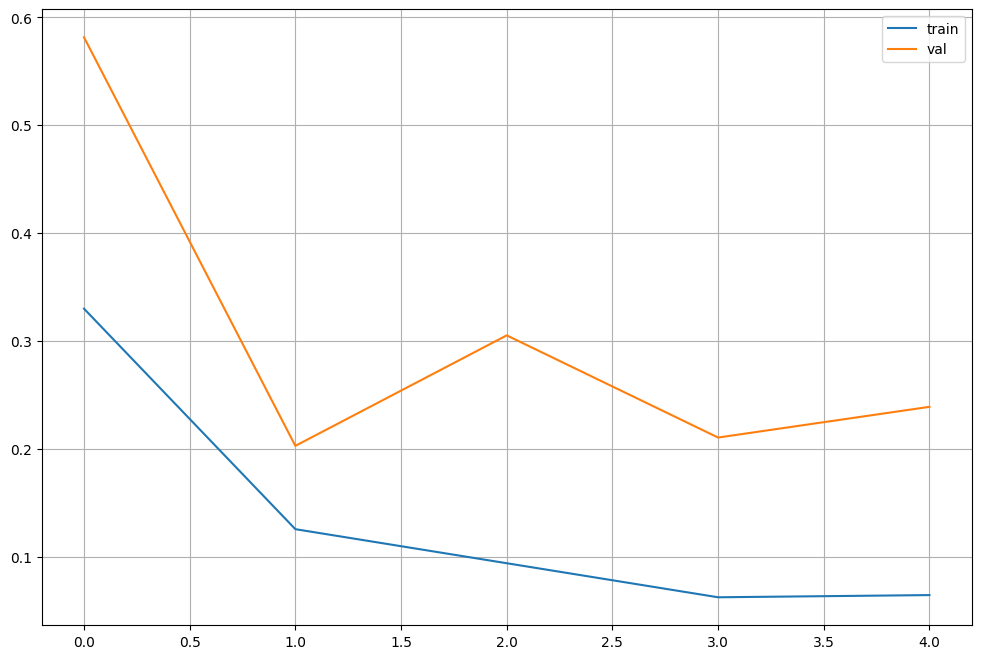

In [30]:
show_metrics(losses_1)

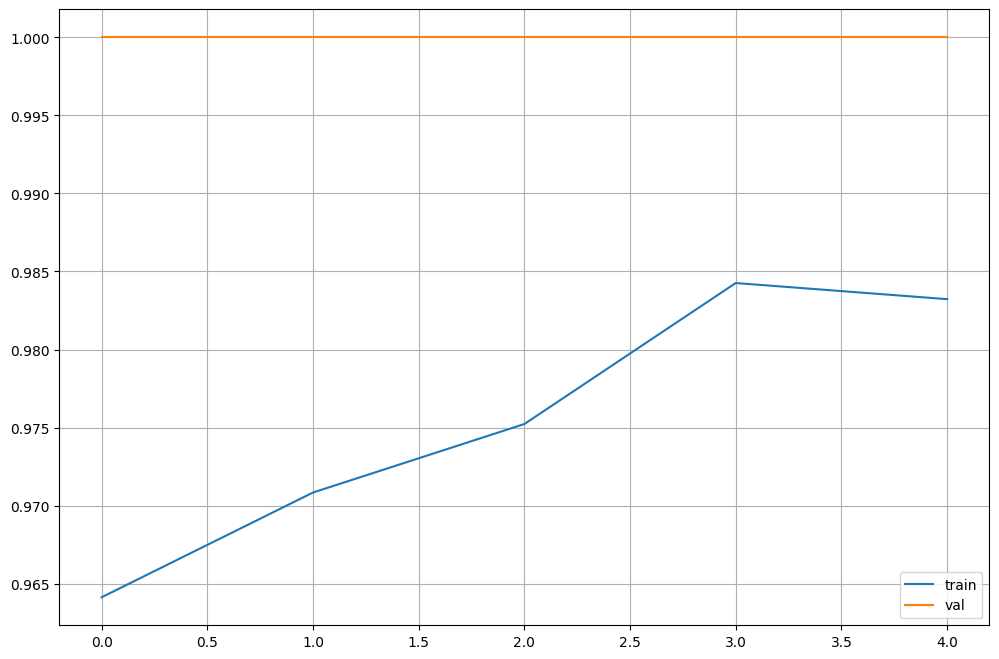

In [31]:
show_metrics(recalls_1)

# Проверка на тестовых

In [32]:
def test(model, device, test_loader, criterion, WANDB=False):

    model.eval()

    test_loss = 0
    correct = 0

    true_pneumonia = 0
    pred_pneumonia = 0
    correct_pneumonia = 0

    pneumonia_label = dataset_classes.index('PNEUMONIA')

    with torch.no_grad():
        for data, target in test_loader:

            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target)

            test_loss += loss.item() * data.size(0)

            pred = output.argmax(dim=1)

            correct += torch.sum(pred == target).item()

            true_pneumonia += torch.sum(target == pneumonia_label).item()
            pred_pneumonia += torch.sum(pred == pneumonia_label).item()
            correct_pneumonia += torch.sum((pred == pneumonia_label) & (target == pneumonia_label)).item()

    test_loss = test_loss / len(test_loader.dataset)
    test_accuracy = correct / len(test_loader.dataset)

    if pred_pneumonia != 0:
        test_precision = correct_pneumonia / pred_pneumonia
    else:
        test_precision = 0

    if true_pneumonia != 0:
        test_recall = correct_pneumonia / true_pneumonia
    else:
        test_recall = 0

    if test_precision + test_recall != 0:
        test_f1 = 2 * test_precision * test_recall / (test_precision + test_recall)
    else:
        test_f1 = 0

    tqdm.write('Test set: Average loss: {:.4f}, Accuracy: {:.2f}%'.format(
        test_loss,
        100. * test_accuracy
    ))

    print('Test precision:', round(test_precision, 4))
    print('Test recall:', round(test_recall, 4))
    print('Test F1-score:', round(test_f1, 4))

    if WANDB:
        wandb.log({
            'test_loss': test_loss,
            'test_accuracy': test_accuracy,
            'test_precision': test_precision,
            'test_recall': test_recall,
            'test_f1': test_f1
        })

    return test_loss, test_accuracy, test_precision, test_recall, test_f1

In [33]:
test_loss_1, test_accuracy_1, test_precision_1, test_recall_1, test_f1_1 = test(
    model=model_1,
    device=DEVICE,
    test_loader=dataloader['test'],
    criterion=criterion,
    WANDB=CFG.wandb
)

Test set: Average loss: 0.6693, Accuracy: 77.56%
Test precision: 0.7451
Test recall: 0.9744
Test F1-score: 0.8444


In [34]:
metrics_result = pd.DataFrame({
    'metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'value': [test_accuracy_1, test_precision_1, test_recall_1, test_f1_1]
})

metrics_result

,metric,value
0,Accuracy,0.775641
1,Precision,0.745098
2,Recall,0.974359
3,F1-score,0.844444


Доп источники: https://colab.research.google.com/github/corrieann/kaggle/blob/master/kaggle_api_in_colab.ipynb

https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html

https://docs.wandb.ai/models/artifacts